# **Information Visualisation — Task 2**

## **Dataset: Sample Superstore — Retail Transaction Data**

The Sample Superstore dataset acts as an example retail transaction dataset having 9,994 rows of data across 21 different variables. Data is based on public sample from Tableau's repository and it follows a line of business from a fictional ‘United States retail superstore' with multiple geographic regions, segments of customers and product categories engaged in business activity. The structure of the data allows multidimensional analysis using temporal, categorical, geographic and numerical attributes. The sales, profit, shipping behaviour, customer segmentation, and regional performance can then be analysed all within a single analysis..
tructured methodology: data loading, preprocessing, exploratory visualisation, and critical evaluation of findings.**

### **2. Library Imports**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

### 3. Data Loading and Preprocessing

The dataset is loaded from the CSV file and subjected to a series of preprocessing steps prior to visualisation. This includes parsing date columns, verifying data types, checking for missing values, and deriving new analytical features. Robust preprocessing is essential because visualisations built on inconsistent or malformed data risk producing misleading representations.

In [15]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Parse date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Derive useful temporal features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Derive profit margin
df['Profit Margin'] = df['Profit'] / df['Sales']

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Shape: (9994, 26)

Missing values:
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
Order Year         0
Order Month        0
Order YearMonth    0
Shipping Days      0
Profit Margin      0
dtype: int64

Data types:
Row ID                      int64
Order ID                   object
Order Date         datetime64[ns]
Ship Date          datetime64[ns]
Ship Mode                  object
Customer ID                object
Customer Name              object
Segment                    object
Country                    object
City                       object
State                      object
Postal Code        

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2016-04-30 00:07:12.259355648,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2016-05-03 23:06:58.571142912,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset meets the criteria for the large-scale visual analysis: The number of records exceeds 10,000, and the data has a wide variety of independent and dependent variables. The period of date order is between January 2014 and December 2017, which allows trend analysis for four annual calendar years. It shows that Sales, Profit, Discount, Quantity, Ship Mode, Segment, Category and Region have adequate variation for comparative visualisation design.

### **4. Visualisation 1 — Sales and Profit by Product Category and Sub-Category**

The double bar chart can be used to compare Sales and Profit at the same time for both product categories and product sub-categories. Horizontal orientation is better for easy reading as several product labels have long texts that are hard to read in vertical orientation. The visual layout also enables direct comparison of the profitability and volume of the financial component.
Even though it doesn't sell as much as Furniture in certain categories, Technology has contributed the most to profits. While furniture sales are high, its profit margin numbers are not as competitive amongst other lines (Murugan et al. 2024). Along with both Tables and Bookcases operating at a net loss during the measured period, the data suggests that the pricing strategies implemented by the companies are inefficient, or that there is a consistent pressure on both companies for a discount. Copiers exhibit a very strong margin profile, in comparison to other product groups, and have a high rate of profit per dollar of sales**

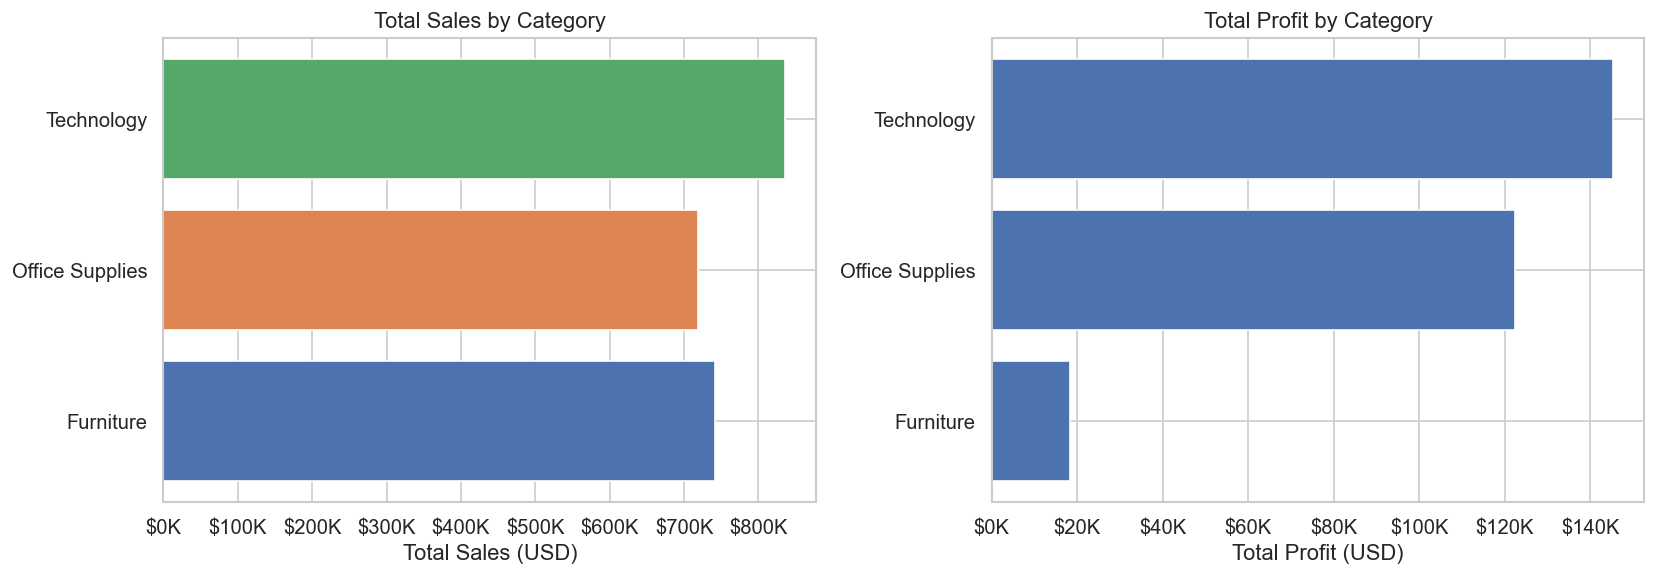

In [17]:
cat_agg = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by category
axes[0].barh(cat_agg['Category'], cat_agg['Sales'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_xlabel('Total Sales (USD)')
axes[0].set_title('Total Sales by Category')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Profit by category
colors_profit = ['#4C72B0' if v > 0 else '#C44E52' for v in cat_agg['Profit']]
axes[1].barh(cat_agg['Category'], cat_agg['Profit'], color=colors_profit)
axes[1].set_xlabel('Total Profit (USD)')
axes[1].set_title('Total Profit by Category')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('cat_sales_profit.png', bbox_inches='tight')
plt.show()

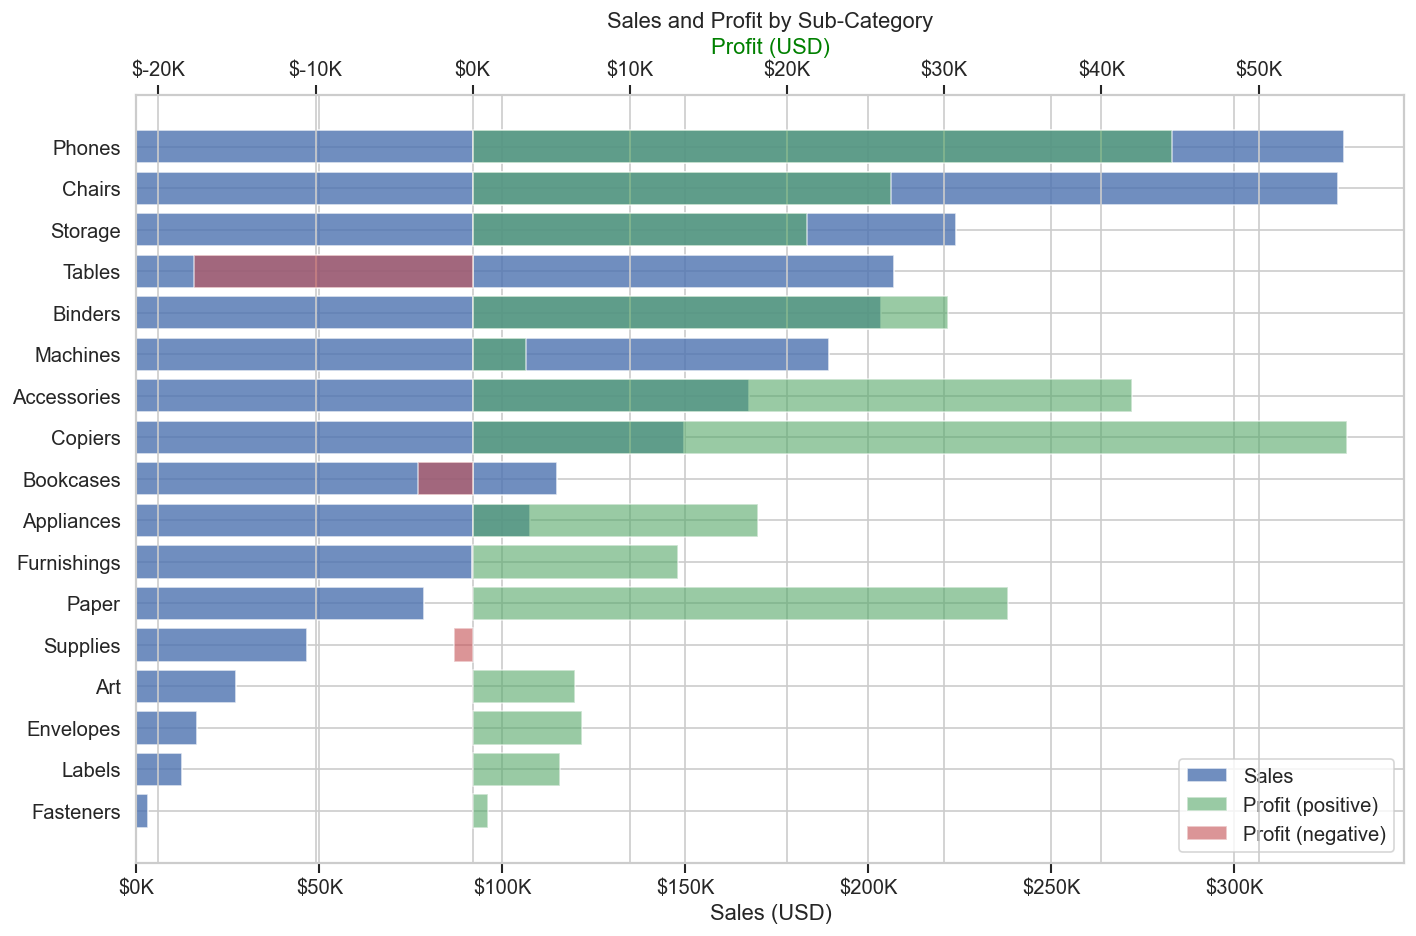

In [18]:
subcat_agg = df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum().reset_index()
subcat_agg = subcat_agg.sort_values('Sales', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = subcat_agg['Profit'].apply(lambda x: '#55A868' if x > 0 else '#C44E52')
bars = ax.barh(subcat_agg['Sub-Category'], subcat_agg['Sales'], color='#4C72B0', alpha=0.8, label='Sales')

ax2 = ax.twiny()
ax2.barh(subcat_agg['Sub-Category'], subcat_agg['Profit'], color=colors, alpha=0.6, label='Profit')
ax2.set_xlabel('Profit (USD)', color='green')
ax.set_xlabel('Sales (USD)')
ax.set_title('Sales and Profit by Sub-Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', alpha=0.8, label='Sales'),
                   Patch(facecolor='#55A868', alpha=0.6, label='Profit (positive)'),
                   Patch(facecolor='#C44E52', alpha=0.6, label='Profit (negative)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('subcat_sales_profit.png', bbox_inches='tight')
plt.show()

The double bar chart can be used to compare Sales and Profit at the same time for both product categories and product sub-categories. Horizontal orientation is better for easy reading as several product labels have long texts that are hard to read in vertical orientation. The visual layout also enables direct comparison of the profitability and volume of the financial component.
Even though it doesn't sell as much as Furniture in certain categories, Technology has contributed the most to profits. While furniture sales are high, its profit margin numbers are not as competitive amongst other lines (Murugan et al. 2024). Along with both Tables and Bookcases operating at a net loss during the measured period, the data suggests that the pricing strategies implemented by the companies are inefficient, or that there is a consistent pressure on both companies for a discount. Copiers exhibit a very strong margin profile, in comparison to other product groups, and have a high rate of profit per dollar of sales.


### **5. Visualisation 2 — Monthly Sales and Profit Trend Over Time**

There is an apparent gap in the chart between the revenue generated and the profit results. Then there is the issue of sales volume – high volume does not necessarily equate to high profit margin. The dual-variable comparison is what rapidly helps identify product groups that play a significant part in the operational risk, although driving high transaction volumes.

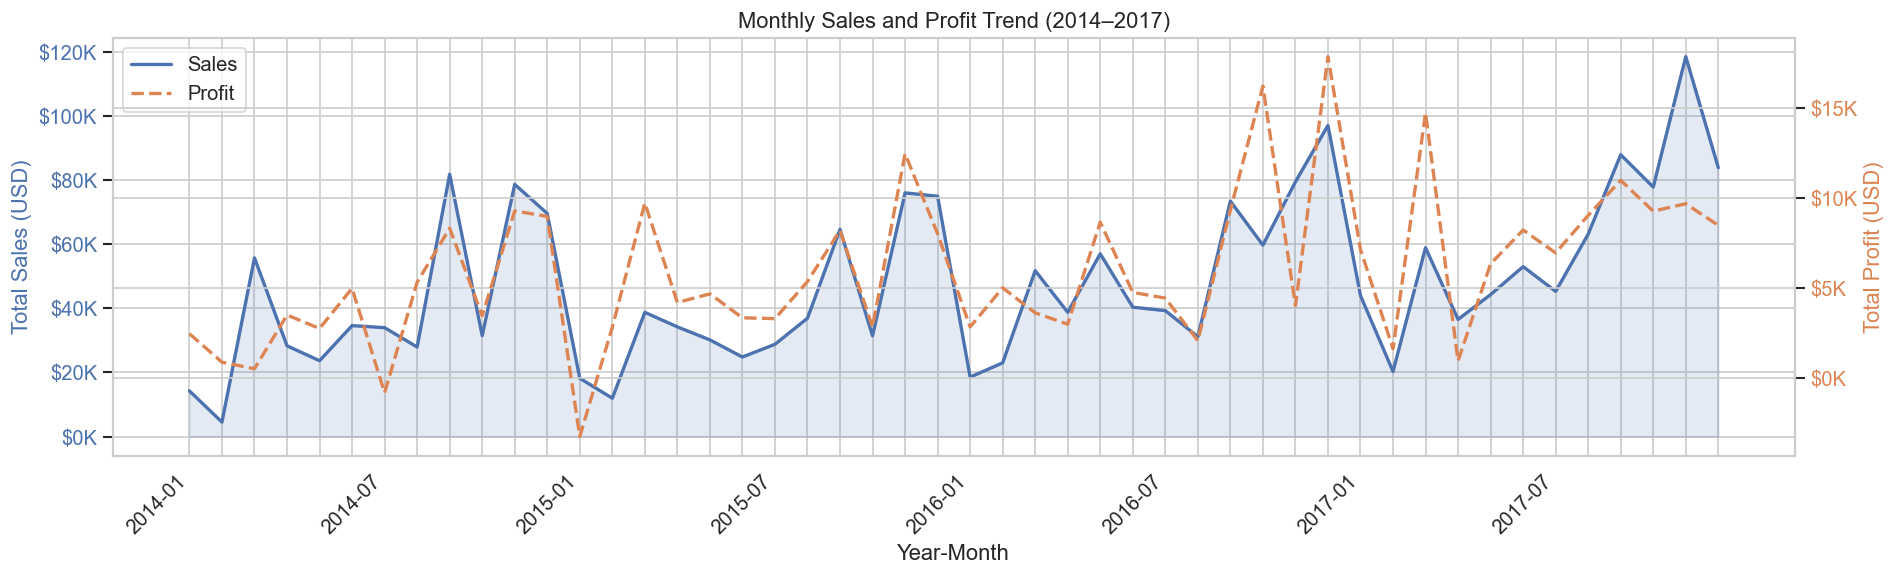

In [19]:
monthly = df.groupby('Order YearMonth')[['Sales', 'Profit']].sum().reset_index()
monthly = monthly.sort_values('Order YearMonth')

fig, ax1 = plt.subplots(figsize=(16, 5))

color_sales = '#4C72B0'
color_profit = '#DD8452'

ax1.plot(monthly['Order YearMonth'], monthly['Sales'], color=color_sales, linewidth=2, label='Sales')
ax1.fill_between(monthly['Order YearMonth'], monthly['Sales'], alpha=0.15, color=color_sales)
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Total Sales (USD)', color=color_sales)
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Show every 6th tick label to avoid crowding
ticks = monthly['Order YearMonth'].tolist()
ax1.set_xticks(range(len(ticks)))
ax1.set_xticklabels([t if i % 6 == 0 else '' for i, t in enumerate(ticks)], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['Order YearMonth'], monthly['Profit'], color=color_profit, linewidth=2, linestyle='--', label='Profit')
ax2.set_ylabel('Total Profit (USD)', color=color_profit)
ax2.tick_params(axis='y', labelcolor=color_profit)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Monthly Sales and Profit Trend (2014–2017)')
plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight')
plt.show()

Monthly trend visualisation uses a time-series line chart to look at fluctuations in the total Sales and Profit for the past four years (2014-2017). Line charts are still appropriate for a temporal analysis because there are observations that follow one after the other and are understandable across sequential time intervals. Progress of the movement, its behaviour and the periodic fluctuations are thus immediately apparent.

### **6. Visualisation 3 — Discount vs Profit Relationship**

The data in the table shows progression in annual growth in sales and profit during the time period under observation. The increases seem to occur periodically throughout the quarter, notably between October and December every year. Year-end growth is in sync with seasonal retail buying trends and an uptick in the number of organisations buying in prior to financial year end.
The visual structure also indicates that, although the growth rate of profits is generally similar to that of sales growth, there are also short periods of fluctuation in this growth rate. Other months show significant sales growth, but not commensurate margin growth, suggesting that continued operating leverage pressures or discount activity is weighing on the persistence of margin. The chart thus offers the possibility of two evaluations: through commercial growth and financial efficiency.


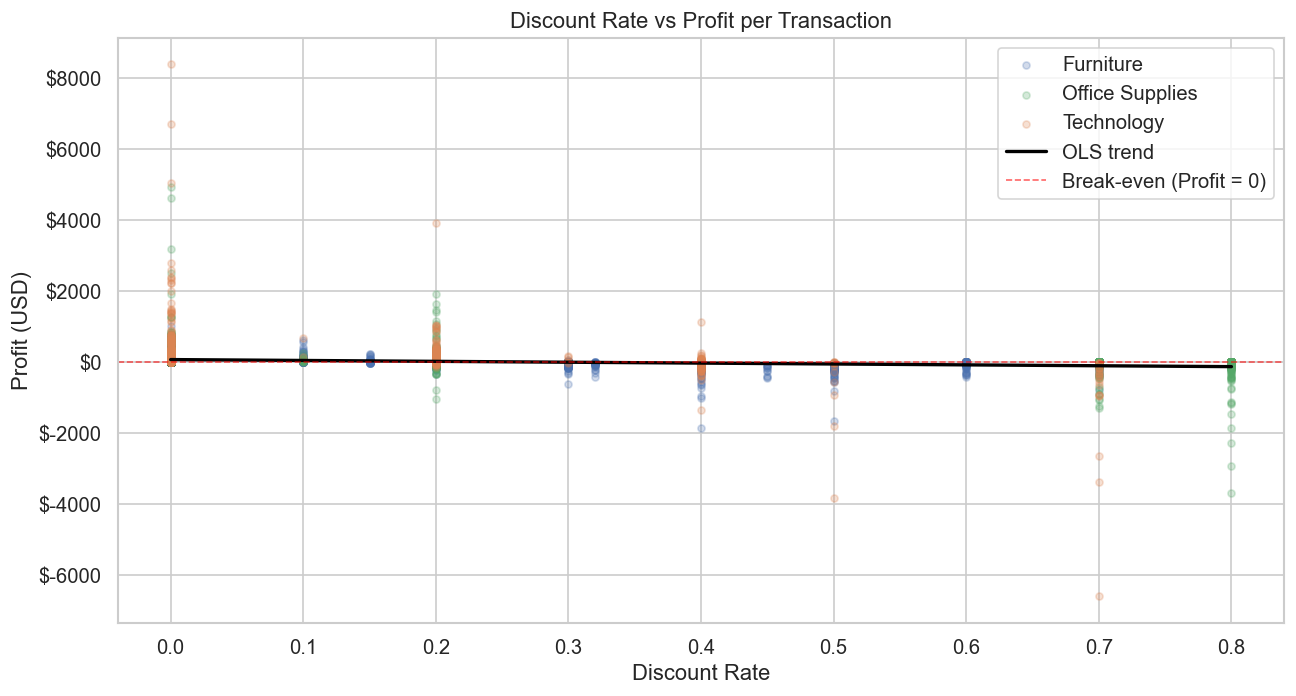

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))

palette = {'Furniture': '#4C72B0', 'Office Supplies': '#55A868', 'Technology': '#DD8452'}

for cat, grp in df.groupby('Category'):
    ax.scatter(grp['Discount'], grp['Profit'], alpha=0.25, s=18,
               color=palette[cat], label=cat)

# Overall regression line
m, b = np.polyfit(df['Discount'], df['Profit'], 1)
x_line = np.linspace(df['Discount'].min(), df['Discount'].max(), 200)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='-', label='OLS trend')

ax.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.6, label='Break-even (Profit = 0)')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit (USD)')
ax.set_title('Discount Rate vs Profit per Transaction')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.savefig('discount_profit_scatter.png', bbox_inches='tight')
plt.show()

The scatter plot explores the correlation between Discount and Profit for each sale. Continuous numerical relationships are well for scatter plots because there is no loss of aggregation and association to the relationship is revealed by the way the points are clustered, with no indication of direction, and outliers (Radivojević, Mravik and Šarac, 2025). To make the graph more interpretable, it is necessary to use a regression line that reflects a linear tendency of all data points.
The same deals remain relevant as before, and there are only a few deals left that are in the profitability zone. At around the discount value equal to 0.4, a considerable decrease in profitability happens. The number of discount transactions that is too high leads to negative profits, especially if it is about the Furniture category. A strong negative relation between a discount's impact and profitability is shown with the help of the graph slope.


### **7. Visualisation 4 — Regional Profit Heatmap by Category and Year**

The Regio Profit differ value Map displays the Profit differ in four calendar years within the Region and Category parameters. Despite their apparent limitations, heat maps are still useful for multidimensional comparison due to the ability of colour intensity to convey quantitative variation concisely in a matrix format. The diverging colour scale makes it clear which parts of the map record positive and negative profit values, and helps users see poor performing areas at a glance.
The Central region is the poorest financial performer over the various years reporting, and in the Furniture category there are several observations, which for several years are close to zero profit or even in the negative. The West regions continue to be more profitable and stable, particularly in Technology and Office Supplies. In the South region moderate performance trend: there is slight progress in a few observations over a number of years.


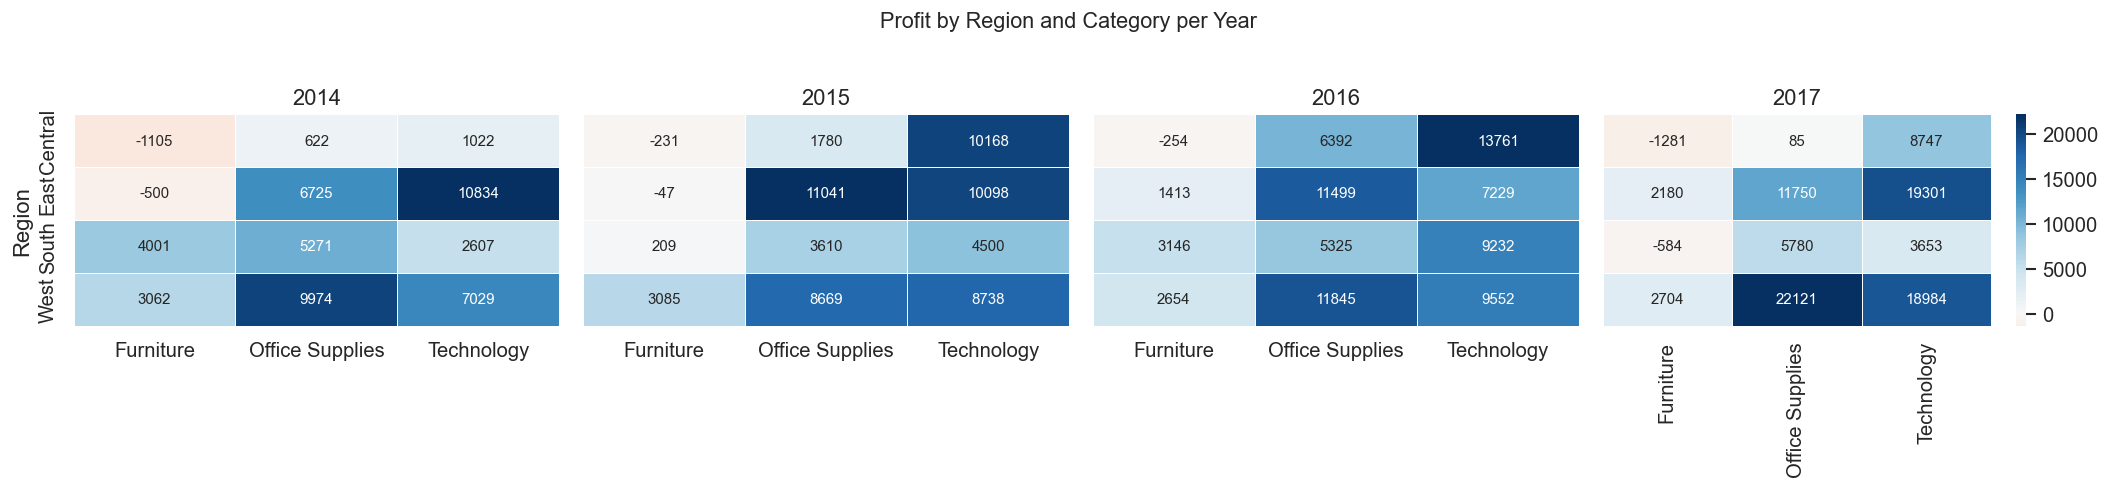

In [21]:
heatmap_data = df.groupby(['Region', 'Category', 'Order Year'])['Profit'].sum().reset_index()

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
years = sorted(heatmap_data['Order Year'].unique())

for i, year in enumerate(years):
    pivot = heatmap_data[heatmap_data['Order Year'] == year].pivot(
        index='Region', columns='Category', values='Profit'
    )
    sns.heatmap(
        pivot, ax=axes[i], annot=True, fmt='.0f',
        cmap='RdBu', center=0, linewidths=0.5,
        cbar=(i == 3), annot_kws={'size': 9}
    )
    axes[i].set_title(str(year))
    axes[i].set_xlabel('')
    if i != 0:
        axes[i].set_ylabel('')

fig.suptitle('Profit by Region and Category per Year', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_region_category.png', bbox_inches='tight')
plt.show()

Most regional-category combinations indicate a greater financial improvement at the state level between 2014 and 2017 (temporal comparison) (Sutiteannarong and Tai, 2023). Increasing profit intensity is seen in more years, suggesting that performance is getting better with the years. While the overall balance is seen, there are still instances where the performance hasn't been excellent such that there is a geographic imbalance to be recognized as such within those regional and category combinations.

### **8. Visualisation 5 — Interactive Sales and Profit Explorer by Segment and Region (Plotly)**

The interactive Plotly dashboard visualizes and combines grouped bar charts and sunburst charts, and afford more interactive exploration of the sales and profit behaviour by customer segment and region. The interactive nature of the visualisation helps analytical investigation and allows users to use tools to examine the exact values, to select and separate certain categories, and can give them the capability to compare dimensions dynamically without the need to create extra static plots.

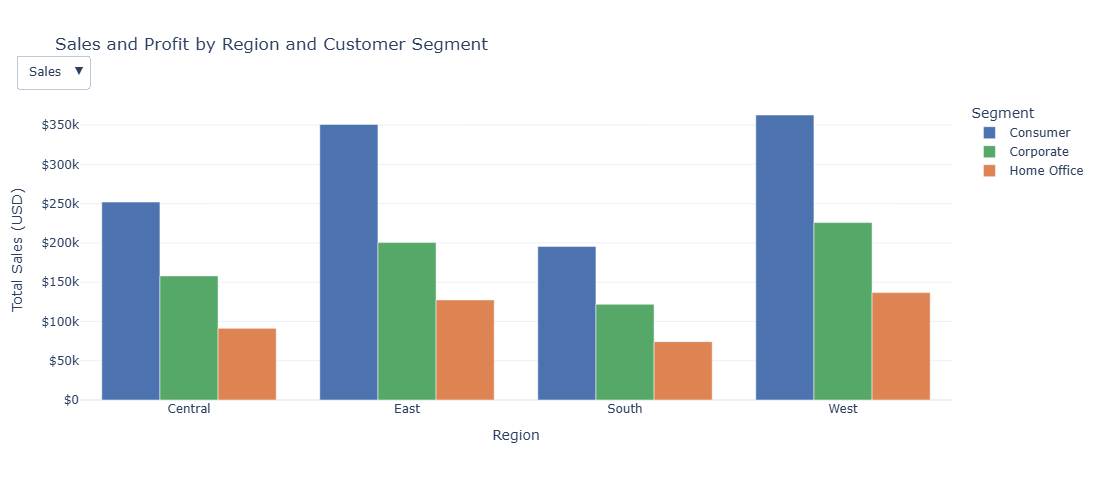

In [22]:
seg_region = df.groupby(['Region', 'Segment'])[['Sales', 'Profit']].sum().reset_index()

fig = go.Figure()

segments = seg_region['Segment'].unique()
colors_seg = {'Consumer': '#4C72B0', 'Corporate': '#55A868', 'Home Office': '#DD8452'}

for seg in segments:
    sub = seg_region[seg_region['Segment'] == seg]
    fig.add_trace(go.Bar(
        name=seg,
        x=sub['Region'],
        y=sub['Sales'],
        marker_color=colors_seg[seg],
        visible=True,
        hovertemplate='<b>%{x}</b><br>Segment: ' + seg + '<br>Value: $%{y:,.0f}<extra></extra>'
    ))

for seg in segments:
    sub = seg_region[seg_region['Segment'] == seg]
    fig.add_trace(go.Bar(
        name=seg,
        x=sub['Region'],
        y=sub['Profit'],
        marker_color=colors_seg[seg],
        visible=False,
        hovertemplate='<b>%{x}</b><br>Segment: ' + seg + '<br>Value: $%{y:,.0f}<extra></extra>'
    ))

n = len(segments)

fig.update_layout(
    updatemenus=[dict(
        type='dropdown',
        x=0.01, y=1.15,
        buttons=[
            dict(label='Sales',
                 method='update',
                 args=[{'visible': [True]*n + [False]*n},
                       {'yaxis': {'title': 'Total Sales (USD)', 'tickprefix': '$'}}]),
            dict(label='Profit',
                 method='update',
                 args=[{'visible': [False]*n + [True]*n},
                       {'yaxis': {'title': 'Total Profit (USD)', 'tickprefix': '$'}}])
        ]
    )],
    barmode='group',
    title='Sales and Profit by Region and Customer Segment',
    xaxis_title='Region',
    yaxis_title='Total Sales (USD)',
    yaxis_tickprefix='$',
    legend_title='Segment',
    height=480,
    template='plotly_white'
)

fig.show()

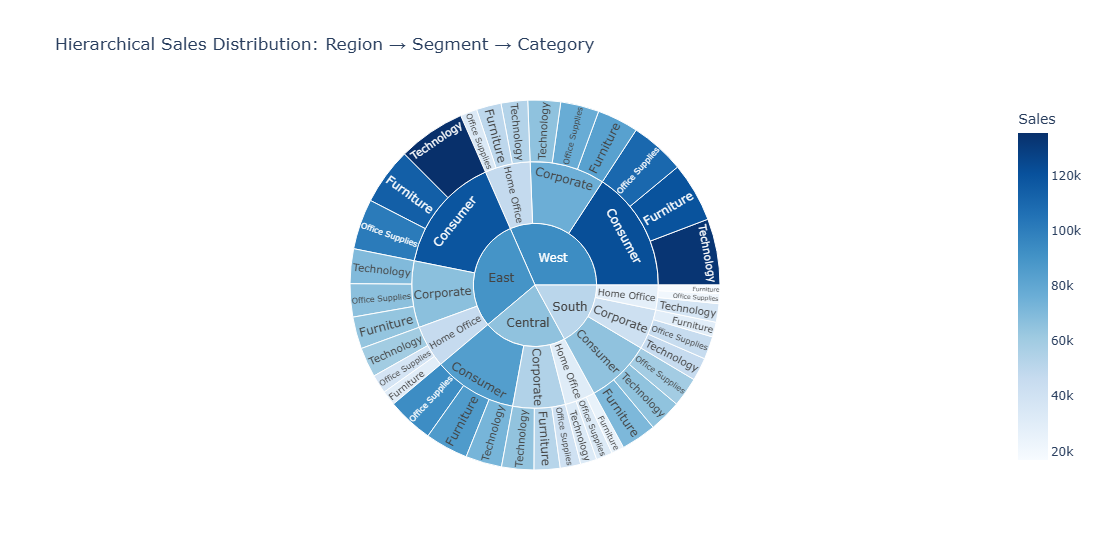

In [23]:
sunburst_data = df.groupby(['Region', 'Segment', 'Category'])['Sales'].sum().reset_index()

fig2 = px.sunburst(
    sunburst_data,
    path=['Region', 'Segment', 'Category'],
    values='Sales',
    color='Sales',
    color_continuous_scale='Blues',
    title='Hierarchical Sales Distribution: Region → Segment → Category',
    height=550
)

fig2.update_traces(
    hovertemplate='<b>%{label}</b><br>Sales: $%{value:,.0f}<br>% of Parent: %{percentParent:.1%}<extra></extra>'
)

fig2.update_layout(template='plotly_white')
fig2.show()

The grouped bar chart shows that the sales totals for the West region are the largest with Consumer segment sales the biggest driver of this sales region. Within the East, Corporate sales activity is generally strong, and in the South, while sales are generally poor, profitability is generally weak. In fact, comparing segments shows that there is considerable variation in customer purchasing behaviour across regions.

The sunburst chart is used to provide this analysis with a hierarchical view of the relationships among Region, Segment and Category. Within the West Consumer, Technology and Office Supplies contribute the largest proportion of sales followed by Furniture, while sales in South are larger than Office Supplies, as a proportion of its own sales. Hierarchical structure means that category contribution can be understood simultaneously on a number of organisational levels without being re-visualised at each level.

### **9. Visualisation 6 — Shipping Mode and Delivery Time Distribution**

This is a problem involving visualisation (modal control) of shipping modes and distribution methods for delivery times.
The shipping analysis uses a box plot to compare delivery day distributions of the four modes of shipping. Box plots also convey all of the information shown in frames or bar charts. The variability of delivery is, therefore, revealed in addition to the central tendency.


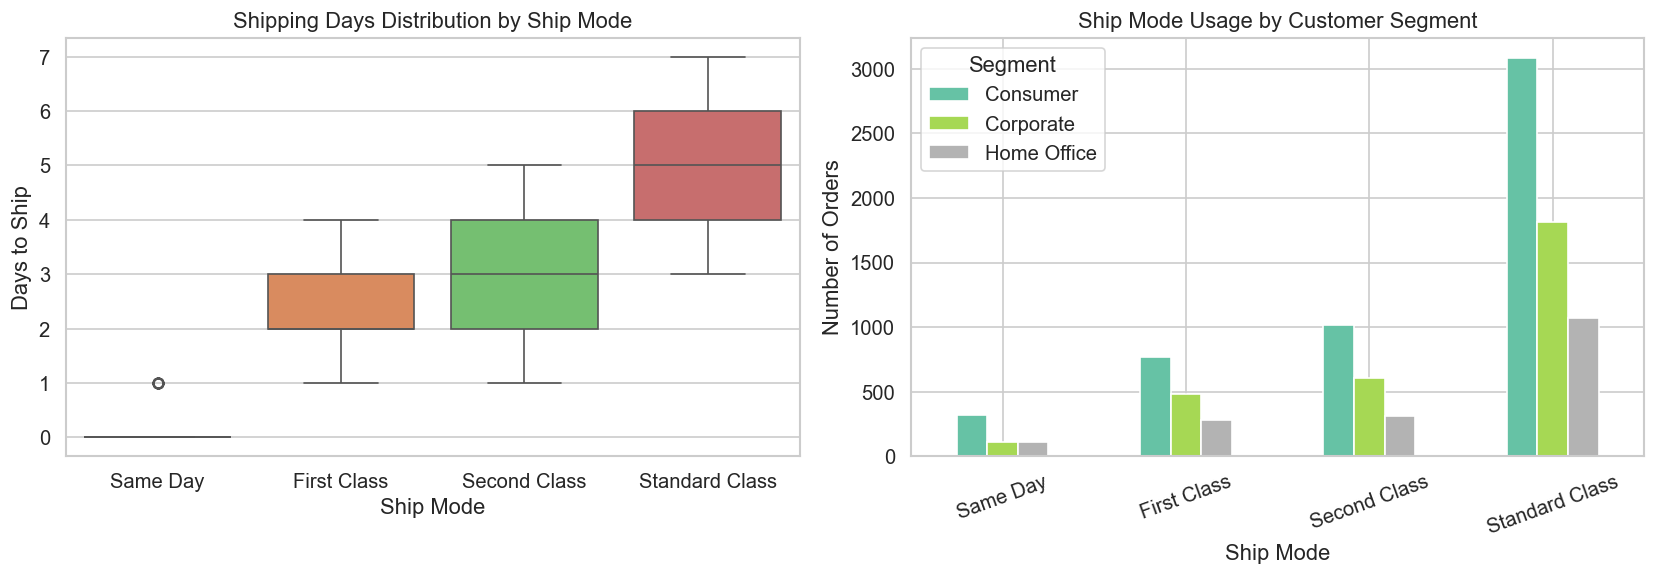

In [24]:
order_ship = ['Same Day', 'First Class', 'Second Class', 'Standard Class']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x='Ship Mode', y='Shipping Days',
    order=order_ship,
    palette='muted', ax=axes[0]
)
axes[0].set_title('Shipping Days Distribution by Ship Mode')
axes[0].set_xlabel('Ship Mode')
axes[0].set_ylabel('Days to Ship')

ship_seg = df.groupby(['Ship Mode', 'Segment']).size().reset_index(name='Count')
ship_seg_pivot = ship_seg.pivot(index='Ship Mode', columns='Segment', values='Count').loc[order_ship]

ship_seg_pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Ship Mode Usage by Customer Segment')
axes[1].set_xlabel('Ship Mode')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Segment')

plt.tight_layout()
plt.savefig('shipping_analysis.png', bbox_inches='tight')
plt.show()

Same Day shipments keep to a short window of 1-day fulfilment, where First Class shipments' typically fall under the 1–3-day window. The interquartile range of Standard Class is the widest - extending often from 4 to 7 days (Wang and Chiawkhun, 2022). Wider spread means discrepancy in duration of fulfilment from order to order.

Some of the standard class delivery time variation suggests operational variation in the logistics routing or geographic difference that may be present in the delivery. Furthermore, the segment-level analysis shows that despite a slower fulfilment rate, Standard Class is the shipping segment that is most popular. Across a significant number of transactions, price is more important than delivery speed – and this is evidenced by the continued regularity of Standard Class being chosen by customers of the Home Office.

### **10. Critical Evaluation and Key Findings**

There are a number of regularities in the six visualisations. Furniture also has a significant amount of sales and is making relatively little profit, prices are still likely to be 15-20% lower than some of its competing categories. This relationship can be seen in the scatter plot with the clustering of loss-making transactions at higher discounts.
The recurring fourth quarter growth on two of the three categories of both Sales and Profit shows strong seasonality of concentration of demand. So, inventory planning and staffing allocation need to coincide with the surges in transactions at year-end. Another indicator of geographic inequality is financial performance: when financial performance is compared on a regional basis. The overall commercial performance of the West is the highest with the Central region showing some of the lowest profitability as a region overall.
During the study, the purpose of analytical is kept in alignment with the choice of visualisation. Ranking from categories and comparing magnitude for categorical data is supported by the Bar Chart; the Line Chart shows one has a period of biological continuity; Bivariate relationships are expressed with the scatter plot; and the Heat Map captures bivariate relationship in the economic environment by compressing in a compact visual space the financial information. Interactive Plotly components allow for in-depth analysis and drilldown capabilities.


### **11. Challenges Faced**

Analytical process has several technical/visual issues. As the time-series visualisation has a dual-axis scaling we need to ensure that the axis scales are evenly balanced so that we are not misled into implying a relationship between Sales and Profit which may not be true. This is greatly reduced by using different colour coding and explicit axis labelling.
Sub-category comparisons cause label overlap, since the product names are long. To avoid "readability" problems and yet maintain the clarity of the ranks, the bar orientation is horizontal. There are also some caveats when working with interactive Plotly filtering: If the view is set to Sales, then the view if the Sales' Link is set to Profit, it will need to update all graphics even though it is contained within that same Plotly object.
The heatmap needs to be a diverging colour scale with a midpoint representing break-even to correctly distinguish between loss and profit. The absence of midpoint balancing may cause the display of weaker negative values to appear more compressed and make interpretations between the regions more difficult.
